In [1]:
import os
import json
import logging
import torch
from math import log2
from matplotlib import pyplot as plt
from dotenv import load_dotenv
from omegaconf import OmegaConf, DictConfig

from whar_datasets.adapters.pytorch import PytorchAdapter
from whar_datasets.support.getter import WHARDatasetID, get_whar_cfg
from flow_matching.latent.autoencoder import AE, AEC, CAE, CAEC
from flow_matching.latent.training_cae import collate_fn, detransform
from flow_matching.whar.models.autoencoder_dynamic import (
    SpectrogramAE,
    SpectrogramCAE,
    SpectrogramAEC,
    SpectrogramCAEC,
)
from flow_matching.whar.stft import decompress_stft, plot_spectrogram_grid

In [2]:
from typing import List, Tuple
from torch import Tensor


def run_script(
    cfg: DictConfig, model_path: str, num_samples: int
) -> Tuple[List[Tensor], List[Tensor], List[float]]:
    # Set up device
    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else ("mps" if torch.backends.mps.is_available() else "cpu")
    )

    datasets_dir = os.environ.get("DATASETS_DIR") or cfg.data.datasets_dir
    num_downsamples = int(log2(cfg.model.size_spect / cfg.model.size_latent))

    # Log info
    log = logging.getLogger(__name__)
    log.info(f"datasets_dir: {datasets_dir}")
    log.info(f"device: {device}")
    log.info(f"cfg: {OmegaConf.to_yaml(cfg, resolve=True)}")
    log.info(f"num_downsamples: {num_downsamples}")

    # Load and configure dataset
    dataset_cfg = get_whar_cfg(WHARDatasetID(cfg.data.dataset_id), datasets_dir)
    dataset_cfg.seed = cfg.train.seed
    dataset_cfg.in_memory = True
    dataset_cfg.in_parallel = True
    dataset = PytorchAdapter(dataset_cfg)

    # Get dataloaders
    train_loader, val_loader, test_loader = dataset.get_dataloaders(
        train_batch_size=cfg.train.batch_size,
        scv_group_index=cfg.data.scv_group_index,
    )
    num_classes = len(dataset.get_class_weights(train_loader))

    # Initialize model
    ae: AE | CAE | AEC | CAEC
    match cfg.model.architecure:
        case "ae":
            ae = SpectrogramAE(
                num_channels_spect=cfg.model.num_channels_spect,
                num_channels_latent=cfg.model.num_channels_latent,
                num_downsamples=num_downsamples,
            )
        case "aec":
            ae = SpectrogramAEC(
                num_channels_spect=cfg.model.num_channels_spect,
                num_channels_latent=cfg.model.num_channels_latent,
                num_classes=num_classes + 1,
                embedding_dim=cfg.model.embedding_dim,
                num_downsamples=num_downsamples,
            )
        case "cae":
            ae = SpectrogramCAE(
                num_channels_spect=cfg.model.num_channels_spect,
                num_channels_latent=cfg.model.num_channels_latent,
                num_classes=num_classes + 1,
                embedding_dim=cfg.model.embedding_dim,
                num_downsamples=num_downsamples,
            )
        case "caec":
            ae = SpectrogramCAEC(
                num_channels_spect=cfg.model.num_channels_spect,
                num_channels_latent=cfg.model.num_channels_latent,
                num_classes=num_classes + 1,
                embedding_dim=cfg.model.embedding_dim,
                num_downsamples=num_downsamples,
            )
        case _:
            raise NotImplementedError

    # Load model weights
    ae.load_state_dict(torch.load(model_path, map_location=device))
    ae.to(device)
    ae.eval()

    # Run one batch through
    test_loader.collate_fn = collate_fn

    originals = []
    recons = []
    tsr_rates = []

    for x, y in test_loader:
        if len(originals) >= num_samples:
            break

        print(x.shape, y.shape)
        recon, z = ae(x.to(device), y.to(device))

        print(recon.min(), recon.max())

        x = x[0].detach().cpu()
        recon = recon[0].detach().cpu()

        # C, H, W = recon.shape

        # x_reshaped = x.reshape(C // 2, 2, H, W)
        # recon_reshaped = recon.reshape(C // 2, 2, H, W)

        # plot_spectrogram_grid(x_reshaped)
        # plot_spectrogram_grid(recon_reshaped)

        # plot_spectrogram_grid(decompress_stft(x_reshaped))
        # plot_spectrogram_grid(decompress_stft(recon_reshaped))

        latent_size = cfg.model.size_latent
        num_latent_channels = cfg.model.num_channels_latent
        original_size = 18 * 32 * 32

        latent_dims = num_latent_channels * (latent_size**2)
        compression_factor = 100 * latent_dims / original_size

        originals.append(detransform(x))
        recons.append(detransform(recon))
        tsr_rates.append(compression_factor)

    return originals, recons, tsr_rates


In [3]:
project = "artifacts:v0"
models = [f"cae_nc18_lc{lc}_ls4" for lc in range(20, 65, 4)]
print(models)
num_samples = 10

originals = []
recons = []
tsr_rates = []

for model in models:
    config_path = f"{project}/config_{model}/config.json"
    model_path = f"{project}/model_{model}/ae.pt"

    with open(config_path, "r") as f:
        cfg_dict = json.load(f)

    # Convert to OmegaConf DictConfig for compatibility
    cfg = OmegaConf.create(cfg_dict)
    assert isinstance(cfg, DictConfig)

    original, recon, tsr = run_script(cfg, model_path, num_samples)
    originals.append(original)
    recons.append(recon)
    tsr_rates.append(tsr)

2025-09-10 10:58:02,046 - whar-datasets - INFO - Creating config hash...
2025-09-10 10:58:02,046 - whar-datasets - INFO - Checking download...
2025-09-10 10:58:02,046 - whar-datasets - INFO - Download exists.
2025-09-10 10:58:02,047 - whar-datasets - INFO - Checking sessions...
2025-09-10 10:58:02,048 - whar-datasets - INFO - Sessions exist.
2025-09-10 10:58:02,048 - whar-datasets - INFO - Validating common format...


['cae_nc18_lc20_ls4', 'cae_nc18_lc24_ls4', 'cae_nc18_lc28_ls4', 'cae_nc18_lc32_ls4', 'cae_nc18_lc36_ls4', 'cae_nc18_lc40_ls4', 'cae_nc18_lc44_ls4', 'cae_nc18_lc48_ls4', 'cae_nc18_lc52_ls4', 'cae_nc18_lc56_ls4', 'cae_nc18_lc60_ls4', 'cae_nc18_lc64_ls4']
[########################################] | 100% Completed | 739.30 ms


2025-09-10 10:58:02,984 - whar-datasets - INFO - Common format validated.
2025-09-10 10:58:02,985 - whar-datasets - INFO - Checking windowing...
2025-09-10 10:58:03,029 - whar-datasets - INFO - Loading config hash...
2025-09-10 10:58:03,030 - whar-datasets - INFO - Windowing exists.
2025-09-10 10:58:03,035 - whar-datasets - INFO - subject_ids: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
2025-09-10 10:58:03,035 - whar-datasets - INFO - activity_ids: [0 1 2 3 4 5]
2025-09-10 10:58:03,040 - whar-datasets - INFO - train: 7201 | val: 801 | test: 1497
2025-09-10 10:58:03,041 - whar-datasets - INFO - Postprocessing...
Loading windows: 100%|██████████| 9499/9499 [00:08<00:00, 1126.53it/s]
2025-09-10 10:58:11,474 - whar-datasets - INFO - Getting normalization parameters...
2025-09-10 10:58:11,794 - whar-datasets - INFO - Loading config hash...
2025-09-10 10:58:11,794 - whar-datasets - INFO - Creating normalization parameters hash...
2025-09-10 10

torch.Size([1, 18, 32, 32]) torch.Size([1])


2025-09-10 10:58:16,093 - whar-datasets - INFO - Creating config hash...
2025-09-10 10:58:16,094 - whar-datasets - INFO - Checking download...
2025-09-10 10:58:16,094 - whar-datasets - INFO - Download exists.
2025-09-10 10:58:16,094 - whar-datasets - INFO - Checking sessions...
2025-09-10 10:58:16,095 - whar-datasets - INFO - Sessions exist.
2025-09-10 10:58:16,095 - whar-datasets - INFO - Validating common format...


...

torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8366, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9343, device='mps:0', grad_fn=<MaxBackward1>)
torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8388, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9318, device='mps:0', grad_fn=<MaxBackward1>)
torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8460, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9356, device='mps:0', grad_fn=<MaxBackward1>)
torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8477, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9303, device='mps:0', grad_fn=<MaxBackward1>)
torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8399, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9275, device='mps:0', grad_fn=<MaxBackward1>)
torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8291, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9314, device='mps:0', grad_fn=<MaxBackward1>)
torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8632, device='mp

2025-09-10 10:59:57,405 - whar-datasets - INFO - Creating config hash...
2025-09-10 10:59:57,405 - whar-datasets - INFO - Checking download...
2025-09-10 10:59:57,406 - whar-datasets - INFO - Download exists.
2025-09-10 10:59:57,406 - whar-datasets - INFO - Checking sessions...
2025-09-10 10:59:57,407 - whar-datasets - INFO - Sessions exist.
2025-09-10 10:59:57,407 - whar-datasets - INFO - Validating common format...


[########################################] | 100% Completed | 662.01 ms


2025-09-10 10:59:58,230 - whar-datasets - INFO - Common format validated.
2025-09-10 10:59:58,230 - whar-datasets - INFO - Checking windowing...
2025-09-10 10:59:58,235 - whar-datasets - INFO - Loading config hash...
2025-09-10 10:59:58,236 - whar-datasets - INFO - Windowing exists.
2025-09-10 10:59:58,242 - whar-datasets - INFO - subject_ids: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
2025-09-10 10:59:58,242 - whar-datasets - INFO - activity_ids: [0 1 2 3 4 5]
2025-09-10 10:59:58,245 - whar-datasets - INFO - train: 7201 | val: 801 | test: 1497
2025-09-10 10:59:58,246 - whar-datasets - INFO - Postprocessing...
Loading windows: 100%|██████████| 9499/9499 [00:06<00:00, 1387.55it/s]
2025-09-10 11:00:05,093 - whar-datasets - INFO - Getting normalization parameters...
2025-09-10 11:00:05,233 - whar-datasets - INFO - Loading config hash...
2025-09-10 11:00:05,233 - whar-datasets - INFO - Creating normalization parameters hash...
2025-09-10 11

torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8516, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9385, device='mps:0', grad_fn=<MaxBackward1>)
torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8496, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9411, device='mps:0', grad_fn=<MaxBackward1>)
torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8455, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9405, device='mps:0', grad_fn=<MaxBackward1>)
torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8509, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9382, device='mps:0', grad_fn=<MaxBackward1>)
torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8497, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9396, device='mps:0', grad_fn=<MaxBackward1>)
torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8538, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9385, device='mps:0', grad_fn=<MaxBackward1>)
torch.Size([1, 18, 32, 32]) torch.Size([1])
tensor(-0.8535, device='mp

In [4]:
print(tsr_rates)

[[1.7361111111111112, 1.7361111111111112, 1.7361111111111112, 1.7361111111111112, 1.7361111111111112, 1.7361111111111112, 1.7361111111111112, 1.7361111111111112, 1.7361111111111112, 1.7361111111111112], [2.0833333333333335, 2.0833333333333335, 2.0833333333333335, 2.0833333333333335, 2.0833333333333335, 2.0833333333333335, 2.0833333333333335, 2.0833333333333335, 2.0833333333333335, 2.0833333333333335], [2.4305555555555554, 2.4305555555555554, 2.4305555555555554, 2.4305555555555554, 2.4305555555555554, 2.4305555555555554, 2.4305555555555554, 2.4305555555555554, 2.4305555555555554, 2.4305555555555554], [2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777], [3.125, 3.125, 3.125, 3.125, 3.125, 3.125, 3.125, 3.125, 3.125, 3.125], [3.4722222222222223, 3.4722222222222223, 3.4722222222222223, 3.4722222222222223, 3.4722222222222223, 3.4722222222222223

In [5]:
import matplotlib.pyplot as plt
import numpy as np


def plot_originals_vs_recons(originals, recons, tsr_rates):
    # skip each 2nd
    originals = originals[::3]
    recons = recons[::3]
    tsr_rates = tsr_rates[::3]

    n = len(originals)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 6), gridspec_kw={"hspace": 0.3})

    # Handle case where n=1 (axes won't be 2D)
    if n == 1:
        axes = axes.reshape(2, 1)

    for i, (orig, recon) in enumerate(zip(originals, recons)):
        # Top row - originals
        ax_orig = axes[0, i]
        ax_orig.plot(orig)

        ax_orig.set_title(f"TSR {tsr_rates[i]:.2f}%")
        ax_orig.set_xticks([])
        ax_orig.set_yticks([])

        # Bottom row - reconstructions
        ax_recon = axes[1, i]
        ax_recon.plot(recon)

        ax_recon.set_xticks([])
        ax_recon.set_yticks([])

    # Add row labels
    axes[0, 0].set_ylabel("Originals", fontsize=12, fontweight="bold")
    axes[1, 0].set_ylabel("Reconstructions", fontsize=12, fontweight="bold")

    # plt.tight_layout()
    plt.show()

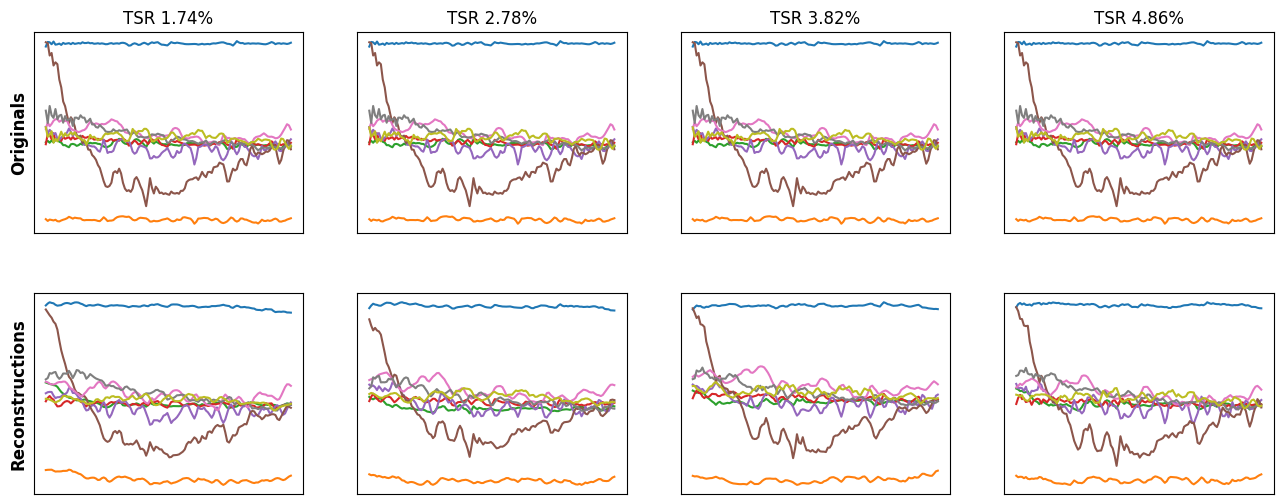

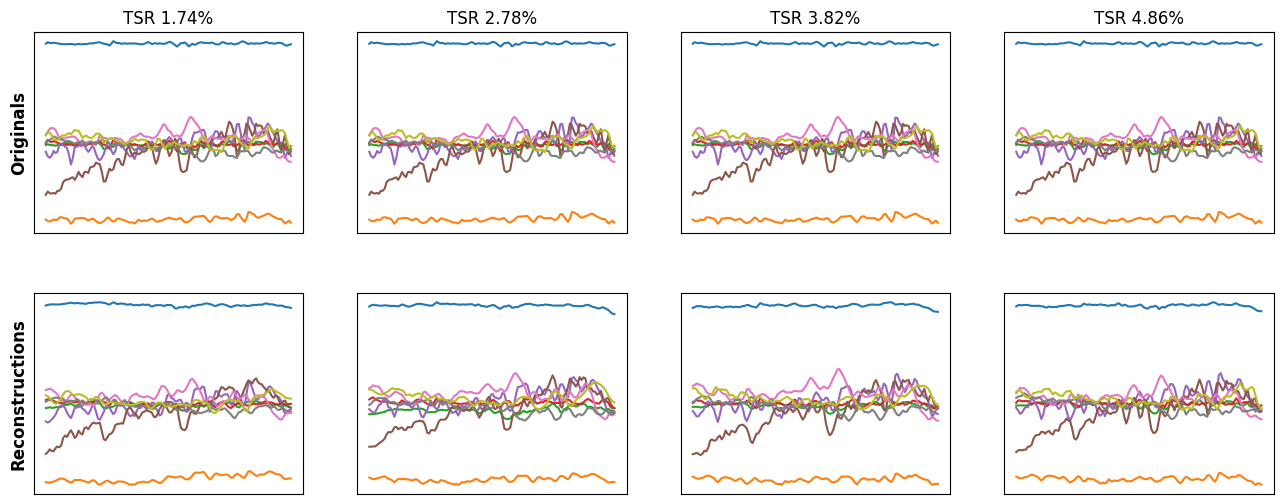

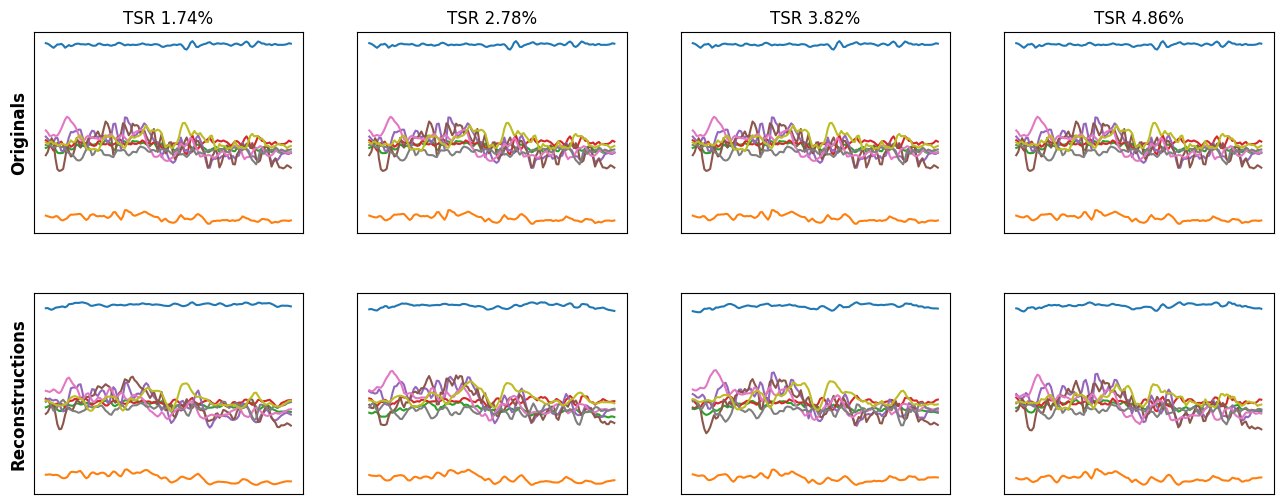

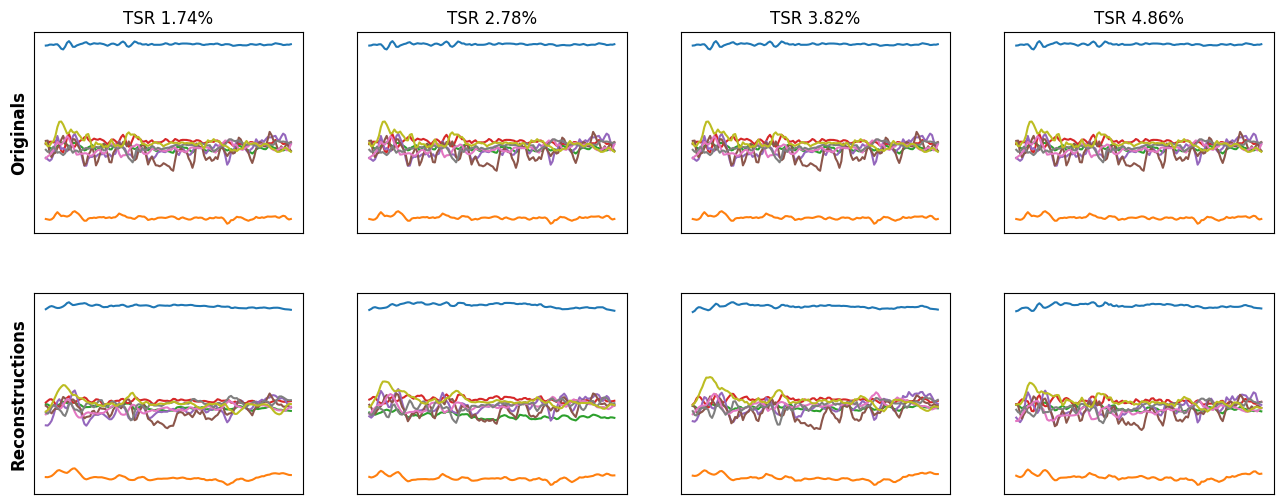

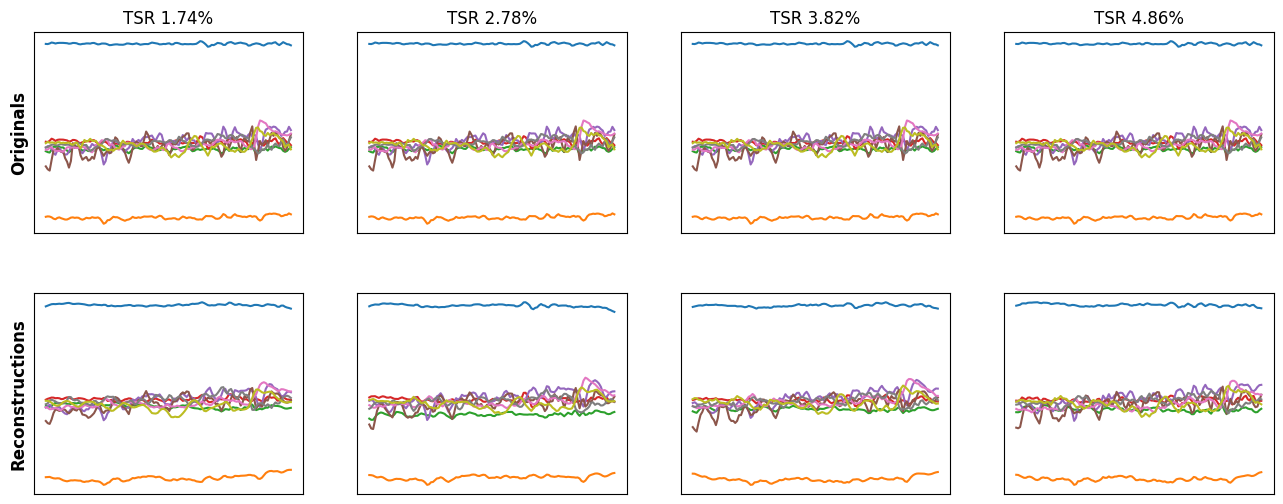

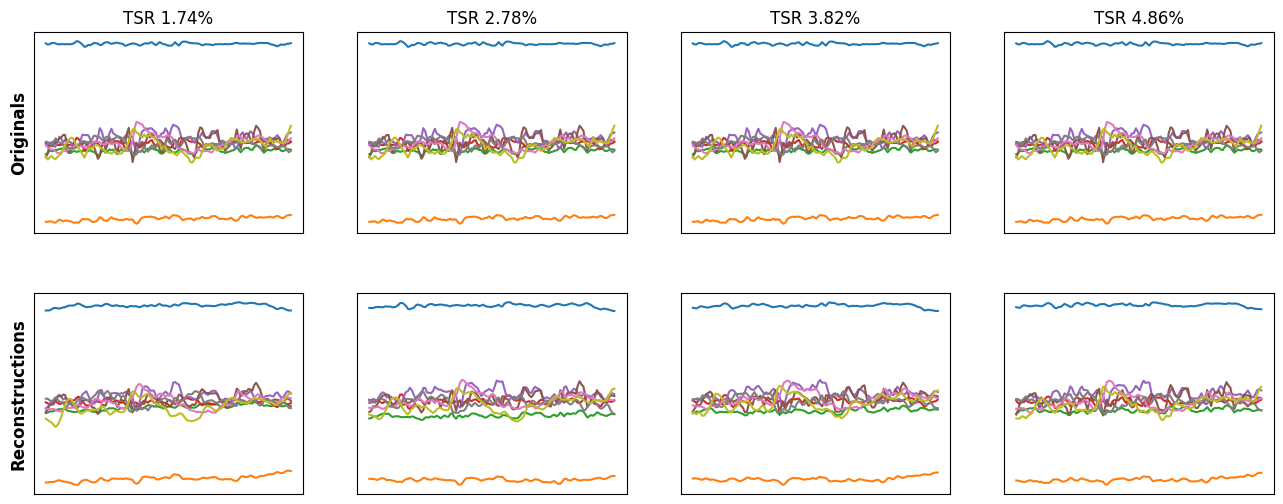

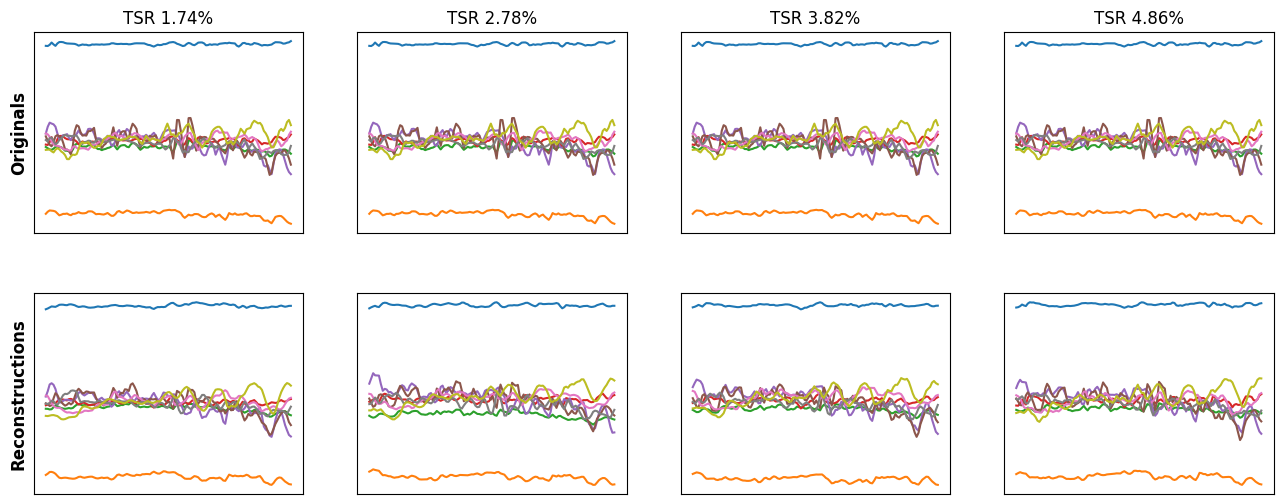

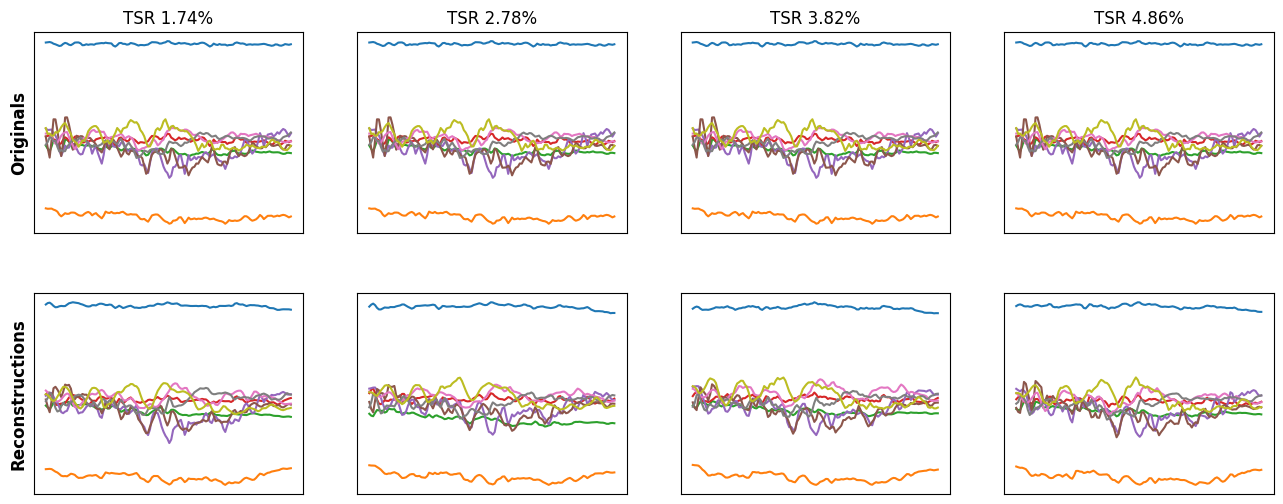

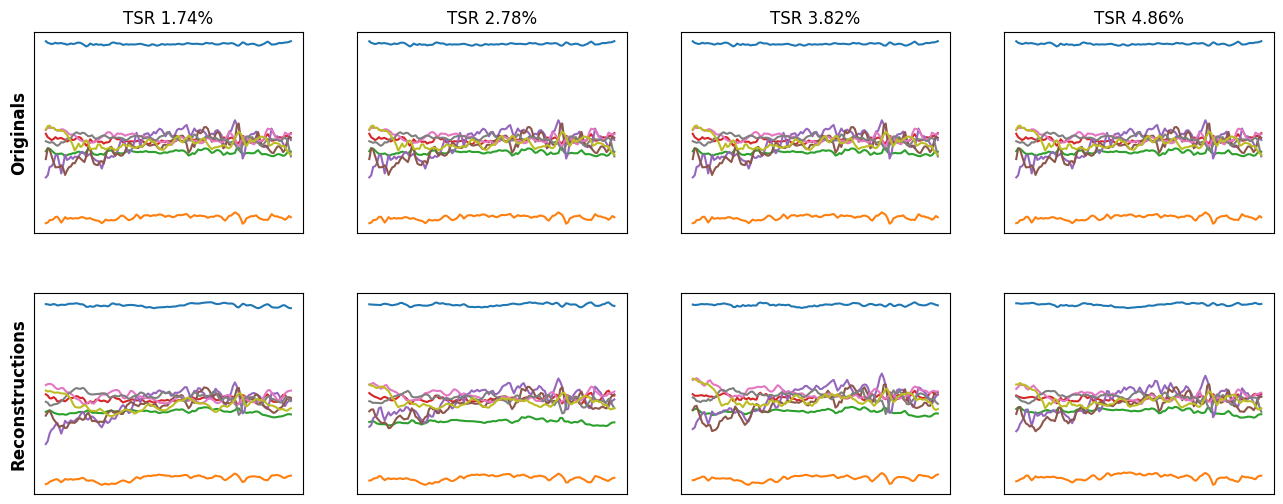

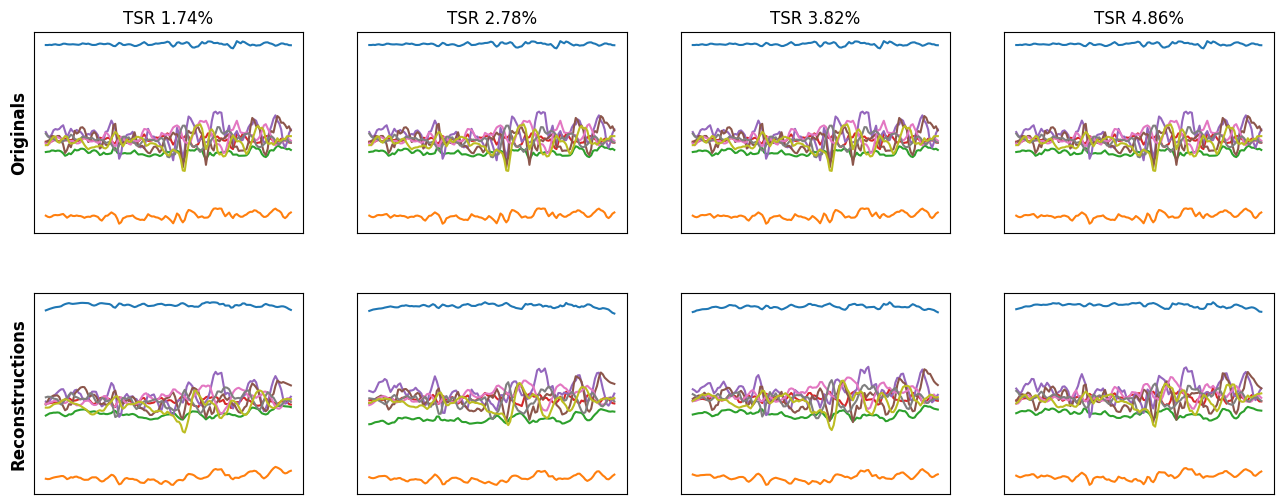

In [7]:
for i in range(len(originals[0])):
    o = [originals[j][i] for j in range(len(originals))]
    r = [recons[j][i] for j in range(len(recons))]
    t = [tsr_rates[j][i] for j in range(len(tsr_rates))]
    plot_originals_vs_recons(o, r, t)